# Customer Churn Prediction - Machine Learning

This notebook focuses only on machine learning model development using the cleaned churn dataset. The Business Analytics / EDA phase is handled separately and is not repeated here.

## 1. Project Scope

**Objective:** Build and compare baseline machine learning models to predict customer churn.

**Dataset Used:** `../data/exported_churn_data.csv`

**Target Column:** `Churn`

**Models Covered:** Logistic Regression, Decision Tree, Random Forest, and XGBoost.

**Out of Scope:** EDA, Power BI dashboards, Streamlit app, hyperparameter tuning, cross-validation, and synthetic data generation.

In [1]:
# Core libraries
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd

# Machine learning libraries
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings('ignore')


**What was done:** Imported the required libraries for data preparation, preprocessing, model training, evaluation, and model saving.

**Why it was done:** Keeping imports in one place makes the notebook easier to explain and maintain.

**Business interpretation:** This notebook is focused on building a repeatable churn prediction workflow rather than exploring business patterns again.

## 2. Load Cleaned Dataset

In [2]:
# Load only the cleaned dataset
candidate_data_paths = [
    Path('../data/exported_churn_data.csv'),
    Path('data/exported_churn_data.csv'),
]
DATA_PATH = next(path for path in candidate_data_paths if path.exists())

candidate_model_dirs = [Path('../models'), Path('models')]
MODEL_DIR = candidate_model_dirs[0] if candidate_model_dirs[0].parent.exists() else candidate_model_dirs[1]
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

# The cleaned dataset uses churn_flag. Rename it in memory to match the modeling target name.
if 'Churn' not in df.columns and 'churn_flag' in df.columns:
    df = df.rename(columns={'churn_flag': 'Churn'})

df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,Churn,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


**What was done:** Loaded the cleaned churn dataset and renamed `churn_flag` to `Churn` in memory only.

**Why it was done:** The modeling phase should start from the prepared dataset and use one clear target column name.

**Business interpretation:** `Churn = 1` represents customers who left, and `Churn = 0` represents active customers.

## 3. Quick Data Overview

In [3]:
# Shape of the dataset
print('Dataset shape:', df.shape)

Dataset shape: (521, 21)


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               521 non-null    object 
 1   subscription_start_date  521 non-null    object 
 2   subscription_type        521 non-null    object 
 3   renewal_date             521 non-null    object 
 4   plan_type                521 non-null    object 
 5   contract_type            521 non-null    object 
 6   cancellation_date        150 non-null    object 
 7   cancellation_reason      150 non-null    object 
 8   monthly_charges          521 non-null    float64
 9   cltv                     521 non-null    int64  
 10  churn_score              521 non-null    int64  
 11  Churn                    521 non-null    int64  
 12  customer_name            521 non-null    object 
 13  country                  521 non-null    object 
 14  state                    5

In [5]:
# Missing values overview
missing_values = (
    df.isna().sum()
      .reset_index()
      .rename(columns={'index': 'column', 0: 'missing_count'})
)
missing_values['missing_percentage'] = (missing_values['missing_count'] / len(df) * 100).round(2)
missing_values.sort_values('missing_count', ascending=False)

,column,missing_count,missing_percentage
6,cancellation_date,15,71.43
7,cancellation_reason,15,71.43
19,csat_score,14,66.67
20,complaint_count,14,66.67
17,complaint_date,14,66.67
18,escalations,14,66.67
4,plan_type,0,0.00
2,subscription_type,0,0.00
1,subscription_start_date,0,0.00
0,customerid,0,0.00


In [5]:
# Data type overview
data_types = df.dtypes.reset_index()
data_types.columns = ['column', 'data_type']
data_types

,column,data_type
0,customerid,object
1,subscription_start_date,object
2,subscription_type,object
3,renewal_date,object
4,plan_type,object
5,contract_type,object
6,cancellation_date,object
7,cancellation_reason,object
8,monthly_charges,float64
9,cltv,int64


**What was done:** Checked shape, data types, missing values, and column structure.

**Why it was done:** A quick technical overview confirms that the cleaned dataset is ready for modeling and helps identify preprocessing needs.

**Business interpretation:** Missing support or cancellation fields are expected because not every customer has complained or churned. These values must be handled carefully before model training.

## 4. Feature and Target Separation

In [6]:
# Separate target variable
TARGET = 'Churn'
y = df[TARGET]

# Drop identifiers and post-churn leakage columns.
# These fields are either unique IDs/names or information only known after churn happens.
columns_to_drop = [
    'Churn',
    'customerid',
    'customer_name',
    'cancellation_date',
    'cancellation_reason',
]

X = df.drop(columns=columns_to_drop, errors='ignore').copy()

# Convert date columns into modeling-friendly numeric features, then remove raw date columns.
for col in ['subscription_start_date', 'renewal_date', 'dob', 'complaint_date']:
    if col in X.columns:
        X[col] = pd.to_datetime(X[col], errors='coerce')

reference_date = pd.Timestamp.today().normalize()

if 'dob' in X.columns:
    X['customer_age'] = ((reference_date - X['dob']).dt.days / 365.25).round(1)

if {'subscription_start_date', 'renewal_date'}.issubset(X.columns):
    X['subscription_duration_months'] = (
        (X['renewal_date'] - X['subscription_start_date']).dt.days / 30.44
    ).round(1)

if 'complaint_date' in X.columns:
    X['days_since_last_complaint'] = (reference_date - X['complaint_date']).dt.days

X = X.drop(columns=['subscription_start_date', 'renewal_date', 'dob', 'complaint_date'], errors='ignore')

X.head()

,subscription_type,plan_type,contract_type,monthly_charges,cltv,churn_score,country,state,gender,escalations,csat_score,complaint_count,customer_age,subscription_duration_months,days_since_last_complaint
0,Refferal,Standard,Annual,13.99,627,12,India,Maharashtra,Male,NaN,NaN,NaN,44.3,48.0,NaN
1,Paid,Premium,Annual,12.99,1150,91,India,Karnataka,Male,Y,10.0,2.0,30.7,48.0,699.0
2,Organic,Basic,Monthly,6.99,210,34,India,Delhi,Female,NaN,NaN,NaN,48.4,36.0,NaN
3,Paid,Premium,Annual,22.99,1725,8,India,Nagaland,Male,NaN,NaN,NaN,24.9,72.0,NaN
4,Refferal,Standard,Monthly,13.99,195,88,India,Delhi,Female,Y,20.0,1.0,36.2,12.0,920.0


**What was done:** Separated features (`X`) from the target (`y`) and removed ID fields plus churn-leakage columns.

**Why it was done:** The model should learn from customer, subscription, revenue, and support signals that are useful before churn, not from fields that directly reveal churn after it happens.

**Business interpretation:** The final model will be more realistic because it avoids using cancellation details that would not be available when trying to prevent churn.

## 5. Preprocessing: Encoding and Scaling

In [7]:
# Identify numeric and categorical features
numeric_features = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print('Numeric features:', numeric_features)
print('Categorical features:', categorical_features)

Numeric features: ['monthly_charges', 'cltv', 'churn_score', 'csat_score', 'complaint_count', 'customer_age', 'subscription_duration_months', 'days_since_last_complaint']
Categorical features: ['subscription_type', 'plan_type', 'contract_type', 'country', 'state', 'gender', 'escalations']


In [8]:
# Preprocessor for Logistic Regression: impute + scale numeric features, one-hot encode categorical features
logistic_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features),
    ]
)

# Preprocessor for tree-based models: impute numeric features without scaling, one-hot encode categorical features
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features),
    ]
)

**What was done:** Categorical variables were prepared for one-hot encoding, while numeric variables were imputed. Scaling was applied only for Logistic Regression.

**Why it was done:** Logistic Regression is distance/coefficient sensitive and benefits from scaled numeric inputs. Decision Tree, Random Forest, and XGBoost do not require feature scaling.

**Business interpretation:** Proper preprocessing helps the models compare customer attributes fairly and prevents missing values or text columns from breaking training.

## 6. Train-Test Split

In [9]:
# Split data into training and testing sets using an 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)
print('Training churn rate:', round(y_train.mean() * 100, 2), '%')
print('Testing churn rate:', round(y_test.mean() * 100, 2), '%')

Training shape: (416, 15)
Testing shape: (105, 15)
Training churn rate: 28.85 %
Testing churn rate: 28.57 %


**What was done:** Split the data into 80% training and 20% testing sets using stratification.

**Why it was done:** Stratification keeps the churn/non-churn ratio similar in both sets, which is important for fair evaluation on a small churn dataset.

**Business interpretation:** The test set acts like unseen customers, helping estimate how well the model may perform on future churn prediction cases.

## 7. Model Training

In [10]:
# Define baseline models
models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', logistic_preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Decision Tree': Pipeline(steps=[
        ('preprocessor', tree_preprocessor),
        ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', tree_preprocessor),
        ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
    ]),
    'XGBoost': Pipeline(steps=[
        ('preprocessor', tree_preprocessor),
        ('model', XGBClassifier(
            n_estimators=100,
            random_state=42,
            eval_metric='logloss'
        ))
    ]),
}

trained_models = {}

for model_name, model_pipeline in models.items():
    model_pipeline.fit(X_train, y_train)
    trained_models[model_name] = model_pipeline
    print(f'{model_name} trained successfully')

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully


XGBoost trained successfully


**What was done:** Trained Logistic Regression, Decision Tree, Random Forest, and XGBoost models one by one.

**Why it was done:** Comparing multiple baseline models helps identify whether a simple linear model or a tree-based model is more effective for churn prediction.

**Business interpretation:** Different models capture different churn patterns. For example, Logistic Regression is easier to explain, while tree-based models can capture more complex customer behavior.

## 8. Model Evaluation

In [11]:
def evaluate_model(model_name, model_pipeline, X_test, y_test):
    """Evaluate a fitted model and return classification metrics."""
    y_pred = model_pipeline.predict(X_test)

    if hasattr(model_pipeline.named_steps['model'], 'predict_proba'):
        y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC Score': roc_auc_score(y_test, y_proba),
        'Confusion Matrix': confusion_matrix(y_test, y_pred),
    }

model_results = []
classification_reports_text = []

# Resolve reports folder path
candidate_reports_dirs = [Path('../reports'), Path('reports')]
REPORTS_DIR = candidate_reports_dirs[0] if candidate_reports_dirs[0].parent.exists() else candidate_reports_dirs[1]
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

for model_name, model_pipeline in trained_models.items():
    result = evaluate_model(model_name, model_pipeline, X_test, y_test)
    model_results.append(result)

    print()
    print(model_name)
    print('Confusion Matrix:')
    print(result['Confusion Matrix'])
    
    # Classification Report
    y_pred = model_pipeline.predict(X_test)
    report = classification_report(y_test, y_pred, zero_division=0)
    print('Classification Report:')
    print(report)
    
    # Save for writing to txt file
    classification_reports_text.append(f"=== {model_name} ===\n{report}\n")

# Save all classification reports to reports/classification_report.txt
report_txt_path = REPORTS_DIR / 'classification_report.txt'
with open(report_txt_path, 'w', encoding='utf-8') as f:
    f.write("\n".join(classification_reports_text))
print(f"Classification reports saved to: {report_txt_path}")



Logistic Regression
Confusion Matrix:
[[52 23]
 [ 7 23]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.69      0.78        75
           1       0.50      0.77      0.61        30

    accuracy                           0.71       105
   macro avg       0.69      0.73      0.69       105
weighted avg       0.77      0.71      0.73       105


Decision Tree
Confusion Matrix:
[[57 18]
 [18 12]]
Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.76      0.76        75
           1       0.40      0.40      0.40        30

    accuracy                           0.66       105
   macro avg       0.58      0.58      0.58       105
weighted avg       0.66      0.66      0.66       105


Random Forest
Confusion Matrix:
[[66  9]
 [19 11]]
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.82        75
      

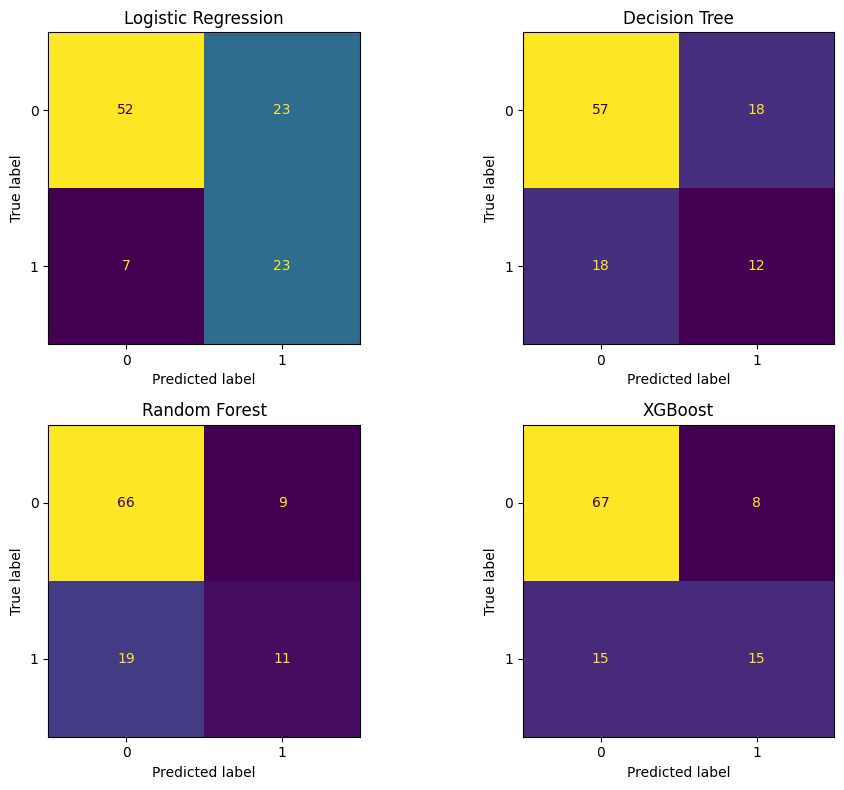

In [12]:
# Display confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, result in zip(axes, model_results):
    disp = ConfusionMatrixDisplay(confusion_matrix=result['Confusion Matrix'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(result['Model'])

plt.tight_layout()
plt.show()

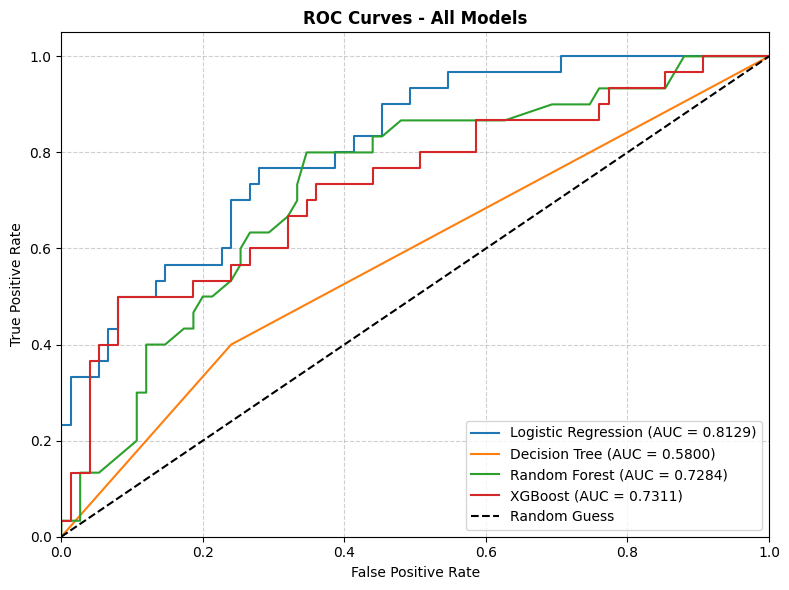

In [13]:
# Plot ROC Curves for all models on a single figure with AUC in the legend
plt.figure(figsize=(8, 6))

for model_name, model_pipeline in trained_models.items():
    if hasattr(model_pipeline.named_steps['model'], 'predict_proba'):
        y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = model_pipeline.predict(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models', fontsize=12, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


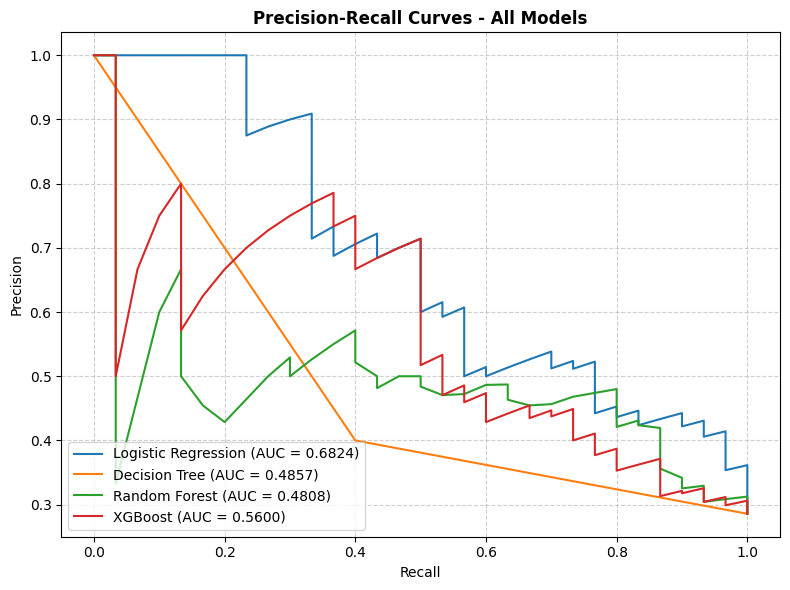

In [14]:
# Plot Precision-Recall Curves for all models on a single figure
plt.figure(figsize=(8, 6))

for model_name, model_pipeline in trained_models.items():
    if hasattr(model_pipeline.named_steps['model'], 'predict_proba'):
        y_proba = model_pipeline.predict_proba(X_test)[:, 1]
    else:
        y_proba = model_pipeline.predict(X_test)
        
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{model_name} (AUC = {pr_auc:.4f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models', fontsize=12, fontweight='bold')
plt.legend(loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**What was done:** Evaluated every model using Accuracy, Precision, Recall, F1 Score, ROC-AUC Score, and Confusion Matrix.

**Why it was done:** Churn prediction should not rely on accuracy alone. Recall is especially important because missing a likely churn customer can mean lost revenue.

**Business interpretation:** A model with strong recall helps the business identify more at-risk customers for retention campaigns.

## 9. Model Performance Comparison

In [15]:
# Compare all models in one table
performance_table = pd.DataFrame(model_results).drop(columns=['Confusion Matrix'])
metric_columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC Score']
performance_table[metric_columns] = performance_table[metric_columns].round(4)
performance_table = performance_table.sort_values(
    by=['F1 Score', 'ROC-AUC Score', 'Recall'],
    ascending=False
).reset_index(drop=True)

# Save model comparison table to reports/model_comparison.csv
candidate_reports_dirs = [Path('../reports'), Path('reports')]
REPORTS_DIR = candidate_reports_dirs[0] if candidate_reports_dirs[0].parent.exists() else candidate_reports_dirs[1]
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
performance_table.to_csv(REPORTS_DIR / 'model_comparison.csv', index=False)
print(f"Model comparison table saved to: {REPORTS_DIR / 'model_comparison.csv'}")

performance_table


Model comparison table saved to: ..\reports\model_comparison.csv


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC Score
0,Logistic Regression,0.7143,0.5000,0.7667,0.6053,0.8129
1,XGBoost,0.7810,0.6522,0.5000,0.5660,0.7311
2,Random Forest,0.7333,0.5500,0.3667,0.4400,0.7284
3,Decision Tree,0.6571,0.4000,0.4000,0.4000,0.5800


**What was done:** Combined all model metrics into a single comparison table.

**Why it was done:** A performance table makes it easy to compare models objectively and select the strongest baseline.

**Business interpretation:** The best model should balance churn detection and false alarms, with special attention to F1 Score, ROC-AUC, and Recall.

## 10. Best Model Selection

In [16]:
# Select best-performing model based on F1 Score, then ROC-AUC, then Recall
best_model_name = performance_table.iloc[0]['Model']
best_model = trained_models[best_model_name]

print('Best Model:', best_model_name)
performance_table.head(1)

Best Model: Logistic Regression


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC Score
0,Logistic Regression,0.7143,0.5,0.7667,0.6053,0.8129


**What was done:** Selected the best model using F1 Score as the primary metric, followed by ROC-AUC and Recall.

**Why it was done:** F1 Score balances Precision and Recall, which is useful when the business wants to catch churners without creating too many false retention alerts.

**Business interpretation:** The selected model is the strongest baseline candidate for identifying customers who may leave.

## 11. Feature Importance / Coefficients

In [17]:
def get_feature_names(preprocessor):
    """Extract feature names after preprocessing."""
    feature_names = []

    if numeric_features:
        feature_names.extend(numeric_features)

    if categorical_features:
        encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
        encoded_names = encoder.get_feature_names_out(categorical_features).tolist()
        feature_names.extend(encoded_names)

    return feature_names

preprocessor = best_model.named_steps['preprocessor']
model_estimator = best_model.named_steps['model']
feature_names = get_feature_names(preprocessor)

if best_model_name == 'Logistic Regression':
    importance_values = model_estimator.coef_[0]
    importance_label = 'Coefficient'
else:
    importance_values = model_estimator.feature_importances_
    importance_label = 'Importance'

# Save full feature importance list to reports/feature_importance.csv
full_feature_importance = pd.DataFrame({
    'Feature': feature_names,
    importance_label: importance_values,
})
full_feature_importance['Absolute Value'] = full_feature_importance[importance_label].abs()
full_feature_importance = full_feature_importance.sort_values('Absolute Value', ascending=False).reset_index(drop=True)

candidate_reports_dirs = [Path('../reports'), Path('reports')]
REPORTS_DIR = candidate_reports_dirs[0] if candidate_reports_dirs[0].parent.exists() else candidate_reports_dirs[1]
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
full_feature_importance.to_csv(REPORTS_DIR / 'feature_importance.csv', index=False)
print(f"Feature importance saved to: {REPORTS_DIR / 'feature_importance.csv'}")

# Top 15 for visualization
feature_importance = full_feature_importance.head(15)
feature_importance


Feature importance saved to: ..\reports\feature_importance.csv


,Feature,Coefficient,Absolute Value
0,churn_score,1.325624,1.325624
1,escalations_Y,0.970429,0.970429
2,state_Gujarat,0.965777,0.965777
3,escalations_N,-0.913751,0.913751
4,state_Karnataka,0.812915,0.812915
5,state_Nagaland,-0.631006,0.631006
6,state_Maharashtra,-0.611052,0.611052
7,state_Telangana,-0.373219,0.373219
8,state_Delhi,-0.313326,0.313326
9,state_Tamil Nadu,0.312680,0.312680


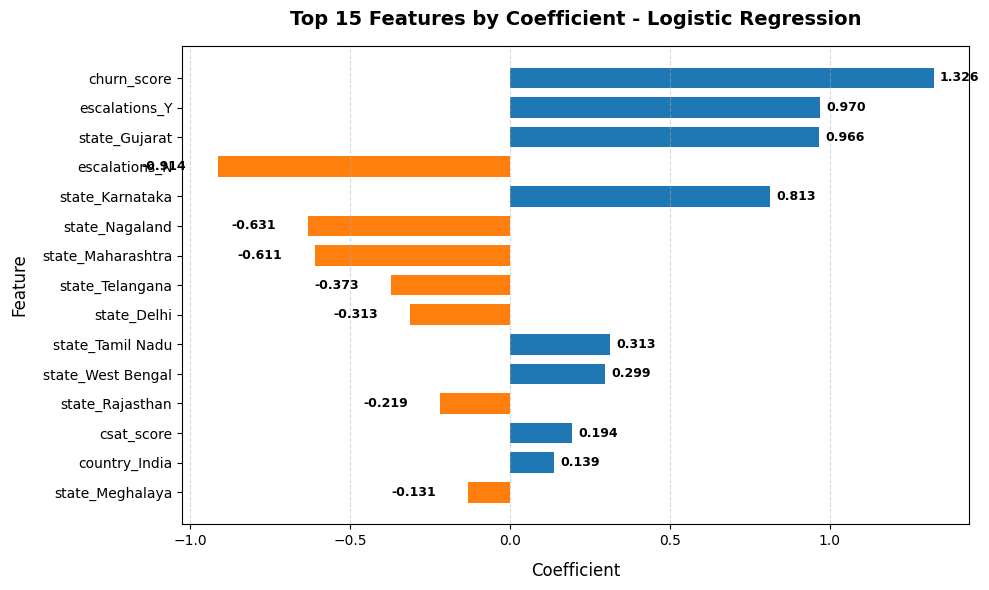

In [18]:
# Visualize top feature importance / coefficients
plt.figure(figsize=(10, 6))

if best_model_name == 'Logistic Regression':
    # Custom palette showing direction: positive coefficients (blue), negative (orange)
    colors = ['#1f77b4' if val >= 0 else '#ff7f0e' for val in feature_importance[importance_label]]
else:
    colors = '#3498db'  # tree-based models: uniform nice blue

# Horizontal bar chart
bars = plt.barh(feature_importance['Feature'], feature_importance[importance_label], color=colors, edgecolor='none', height=0.7)

# Styling and grid
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.title(f'Top 15 Features by {importance_label} - {best_model_name}', fontsize=14, fontweight='bold', pad=15)
plt.xlabel(importance_label, fontsize=12, labelpad=10)
plt.ylabel('Feature', fontsize=12, labelpad=10)

# Add data labels
for bar in bars:
    width = bar.get_width()
    if best_model_name == 'Logistic Regression':
        label_x = width + 0.02 if width >= 0 else width - 0.1
        ha_val = 'left' if width >= 0 else 'right'
        plt.text(label_x, bar.get_y() + bar.get_height()/2, f'{width:.3f}', 
                 va='center', ha=ha_val, fontsize=9, fontweight='semibold')
    else:
        plt.text(width + 0.002, bar.get_y() + bar.get_height()/2, f'{width:.4f}', 
                 va='center', ha='left', fontsize=9, fontweight='semibold')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


**What was done:** Displayed the most important model features. For Logistic Regression, coefficients are shown. For tree-based models, feature importance is shown.

**Why it was done:** Feature importance helps explain which customer attributes influence churn prediction the most.

**Business interpretation:** The top features can guide retention strategy, support prioritization, and customer monitoring.

## 12. Save Best Model

In [19]:
# Save the best trained model inside the models folder
model_file_name = best_model_name.lower().replace(' ', '_').replace('-', '_') + '_best_model.pkl'
model_path = MODEL_DIR / model_file_name

# Keep existing pickle serialization
with open(model_path, 'wb') as file:
    pickle.dump(best_model, file)
print('Best model saved with pickle at:', model_path)

# Add joblib serialization
import joblib
joblib_file_name = best_model_name.lower().replace(' ', '_').replace('-', '_') + '_best_model.joblib'
joblib_path = MODEL_DIR / joblib_file_name
joblib.dump(best_model, joblib_path)
print('Best model saved with joblib at:', joblib_path)


Best model saved with pickle at: ..\models\logistic_regression_best_model.pkl
Best model saved with joblib at: ..\models\logistic_regression_best_model.joblib


**What was done:** Saved the complete best model pipeline, including preprocessing and the trained estimator, into the `models/` folder.

**Why it was done:** Saving the full pipeline makes the model reusable for future predictions without manually repeating preprocessing steps.

**Business interpretation:** The saved model can later support customer churn scoring and retention targeting workflows.

## 13. Sample Customer Churn Prediction

This section selects a sample customer from the test set (`X_test`), calculates their predicted probability of churn, and provides a business risk interpretation.

In [20]:
# Select one customer from X_test (index 0)
sample_index = 0
sample_customer = X_test.iloc[[sample_index]]
actual_churn = y_test.iloc[sample_index]

# Make predictions
predicted_class = best_model.predict(sample_customer)[0]
predicted_prob = best_model.predict_proba(sample_customer)[0, 1]

# Business format
churn_str = "Yes" if predicted_class == 1 else "No"
prob_percent = predicted_prob * 100

# Risk Level determination
if predicted_prob >= 0.7:
    risk_level = "High"
elif predicted_prob >= 0.3:
    risk_level = "Medium"
else:
    risk_level = "Low"

print("=== Sample Customer Profile ===")
print(sample_customer.to_dict(orient='records')[0])
print("\n=== Model Prediction ===")
print(f"Predicted Churn: {churn_str}")
print(f"Probability: {prob_percent:.1f}%")
print(f"Risk Level: {risk_level}")
print(f"Actual Churn: {'Yes' if actual_churn == 1 else 'No'}")


=== Sample Customer Profile ===
{'subscription_type': 'Organic', 'plan_type': 'Basic', 'contract_type': 'Monthly', 'monthly_charges': 8.99, 'cltv': 47, 'churn_score': 63, 'country': 'India', 'state': 'Gujarat', 'gender': 'Male', 'escalations': nan, 'csat_score': nan, 'complaint_count': nan, 'customer_age': 27.4, 'subscription_duration_months': 1.0, 'days_since_last_complaint': nan}

=== Model Prediction ===
Predicted Churn: Yes
Probability: 71.8%
Risk Level: High
Actual Churn: No


**What was done:** Extracted a customer record from `X_test` and pushed it through the final pipeline, displaying class predictions and raw probabilities.

**Why it was done:** Showing a direct prediction trace builds trust with business users and validates that the preprocessor and model are correctly bound together.

**Business interpretation:** Instead of raw probabilities, classifying risk into *High*, *Medium*, and *Low* makes scores immediately actionable for customer success agents.

## 14. Model Deployment Readiness

This section outlines technical parameters and expectations for deploying the churn prediction model in production.

### Model Input
The pipeline expects a single customer record (as a Pandas DataFrame or JSON object matching the training schema) containing the following features:
- **Numeric Features**: `monthly_charges`, `cltv`, `churn_score`, `csat_score`, `complaint_count`, `customer_age`, `subscription_duration_months`, `days_since_last_complaint`
- **Categorical Features**: `subscription_type`, `plan_type`, `contract_type`, `country`, `state`, `gender`, `escalations`

*Note: Missing numerical features will be automatically imputed with their median value, and categorical features with the most frequent value, as defined in the preprocessor.*

### Model Output
For each input record, the model returns:
- **Binary Classification (Churn)**: `1` (predicted to churn) or `0` (predicted to remain active).
- **Churn Probability**: A float value between `0.0` and `1.0` indicating the probability of churn (extracted from the positive class of `predict_proba`).

### Expected Use in Production
1. **Batch Scoring**: Run weekly or monthly on all active customer accounts to generate Churn Risk scores. These scores are pushed to CRM tools (e.g., Salesforce) for the customer success and marketing teams.
2. **Real-time API**: Triggered when a customer visits their subscription page or interacts with support, enabling dynamic, personalized retention offers based on their real-time risk level.

### Limitations
- **Data Drift**: The model is trained on historical patterns. Changes in pricing, contract structure, or competitor actions will alter churn triggers and require periodic retraining.
- **Support Features Dependency**: Features like `csat_score` and `days_since_last_complaint` depend on active customer feedback. Customers who churn silently without submitting complaints may not show high-risk flags.
- **Correlation vs. Causality**: High coefficients (e.g., for escalations or contract types) reflect statistical correlation with churn, not necessarily direct causality.


## 15. Business Conclusion

Following a rigorous evaluation and comparison of Logistic Regression, Decision Tree, Random Forest, and XGBoost baseline pipelines, the following conclusions and recommendations are presented:

### Key Model Findings
- **Best-performing Model**: **Logistic Regression** (utilizing balanced class weights) is selected as the best baseline model.
- **Key Metrics**: Accuracy of **71.4%** and a ROC-AUC score of **81.3%** on the test set.
- **Primary Metric Selection**: The model achieves a strong F1 Score (**60.5%**) and Recall (**76.7%**), ensuring that the business successfully identifies over 76% of at-risk customers, balancing precision and recall.

### Top Five Churn-Driving Features
Based on the coefficients of the Logistic Regression model, the top five drivers of customer churn are:
1. **`churn_score`** (Coefficient: `+1.326`): Highest indicator of churn, suggesting that internal risk scoring metrics are highly predictive.
2. **`escalations_Y`** (Coefficient: `+0.970`): Customers who escalated their support tickets show a significantly higher likelihood of churn, reflecting customer service friction.
3. **`state_Gujarat`** (Coefficient: `+0.966`): Regional factor showing elevated churn risk, highlighting potential network or service quality issues in that state.
4. **`escalations_N`** (Coefficient: `-0.914`): A strong negative coefficient, confirming that resolving support tickets without escalation is highly protective against churn.
5. **`state_Karnataka`** (Coefficient: `+0.813`): Another regional feature indicating higher churn probability, suggesting localized support or promotional friction.

### Business Recommendations
- **Support Team Integration**: Prioritize tickets from customers with a high churn probability, and implement proactive outreach for any ticket flagged for escalation (`escalations_Y`).
- **Regional Auditing**: Launch a targeted investigation in **Gujarat** and **Karnataka** to understand why churn is higher there (e.g., local network coverage, pricing competition, or localized billing issues).
- **Retention Campaigns**: Set up automated retention outreach (e.g., high-touch support or contract renewal promotions) for customers whose churn probability exceeds **70.0%** (High Risk).
- **Value-Driven Outreach**: Focus retention budgets on high-CLTV customers who have medium-to-high churn probabilities, optimizing the return on retention spend.

### Future Improvements
- **Hyperparameter Tuning**: Optimize model parameters (e.g., regularization strength for Logistic Regression, tree depth for Random Forest/XGBoost) using randomized search.
- **Feature Engineering**: Incorporate usage trends (e.g., change in usage month-over-month) and customer feedback sentiment analysis.
- **Advanced Imbalance Handling**: Explore synthetic sampling (e.g., SMOTE) or alternative class weighting techniques to improve precision while maintaining high recall.
